# Monte Carlo dispersion

A 1000-run Monte Carlo around a nominal injection burn. The four perturbed axes are a launch-time-slip proxy (`CoastTime.Value` — extra time on the parking orbit before the burn fires) and the three components of the injection delta-V in the spacecraft's VNB local frame (`Inj.Element1/2/3`). Each run propagates from the parking orbit, applies the perturbed burn, propagates a fixed 1200 s, and reports its final inertial position.

The aggregated DataFrame carries one row per `(run_id, time)` — final-step rows give the per-run arrival point, and the empirical covariance of those arrival points yields the 3-sigma ellipse in the (X, Y) plane.

**Prerequisites.** A local GMAT install (R2026a is the primary development target; see [Supported versions](https://astro-tools.github.io/gmat-sweep/supported-versions/)) and `pip install gmat-sweep[examples]` for the matplotlib dependency.

## Set up the run

Resolve the GMAT install once and confirm the script that ships next to this notebook is where we expect it. The script declares a parking orbit, an `Inj` impulsive burn in VNB, and a `CoastTime` variable that controls the time spent on the parking orbit before the burn fires.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from gmat_run import locate_gmat

from gmat_sweep import expand_monte_carlo_to_run_specs, monte_carlo

install = locate_gmat()
script_path = Path("injection_dispersion.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       injection_dispersion.script
Exists:       True


## Define the perturbations

Four independent perturbed axes:

- `CoastTime.Value` — normal, mean 600 s, 1-sigma 30 s. Models a launch-time slip as extra time on the parking orbit before the burn. Operationally a 30-second slip translates to a 30-second extra coast in the same orbital geometry.
- `Inj.Element1/2/3` — normal, mean (1.0, 0.0, 0.0) km/s, 1-sigma 5 m/s on each axis. The (V, N, B) components of the injection delta-V; the nominal is a 1 km/s burn along the velocity vector and per-axis dispersions are 0.5 % of the along-track magnitude.

The seed is recorded on the manifest the sweep writes; two calls at the same `(n, perturb, seed)` produce bit-equal draws, regardless of process or machine.

In [2]:
SEED = 20260505
N = 1000

perturb = {
    "CoastTime.Value": ("normal", 600.0, 30.0),  # +/- 30 s 1-sigma launch-time slip
    "Inj.Element1": ("normal", 1.0, 0.005),  # +/- 5 m/s along-track 1-sigma
    "Inj.Element2": ("normal", 0.0, 0.005),  # +/- 5 m/s normal 1-sigma
    "Inj.Element3": ("normal", 0.0, 0.005),  # +/- 5 m/s binormal 1-sigma
}

## Run the Monte Carlo

One [`monte_carlo()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.monte_carlo) call dispatches all 1000 runs through the default `LocalJoblibPool`, drains the per-run outcomes in completion order, and returns the aggregated `(run_id, time)`-MultiIndexed DataFrame. With `out=None` the per-run Parquet files land in a temporary directory whose lifetime is tied to the returned DataFrame.

Failed runs would surface as one NaN-filled row each with `__status="failed"`. The perturbations here are small enough relative to the parking orbit's energy that every run completes cleanly.

In [3]:
df = monte_carlo(
    script_path,
    n=N,
    perturb=perturb,
    seed=SEED,
    progress=False,
)
df["__status"].value_counts()

__status
ok    11997
Name: count, dtype: int64

## Final-step arrival points

Group by `run_id` and take the last row per group. The `(Sat.X, Sat.Y, Sat.Z)` of the final time-step is the arrival point in the EarthMJ2000Eq inertial frame.

In [4]:
final = df.groupby(level="run_id").last()
arrivals = final[["Sat.X", "Sat.Y", "Sat.Z"]].to_numpy()

print(f"Arrival points shape: {arrivals.shape}")
print(f"Mean (km):   {arrivals.mean(axis=0).round(3)}")
print(f"Stddev (km): {arrivals.std(axis=0).round(3)}")

Arrival points shape: (1000, 3)
Mean (km):   [-3015.051  6826.621  3706.294]
Stddev (km): [249.009  85.78   46.776]


## Histogram of miss distances

The miss distance for each run is the Euclidean distance from its arrival point to the empirical mean arrival point. The histogram of those distances is the canonical 1-D summary of an N-dimensional dispersion.

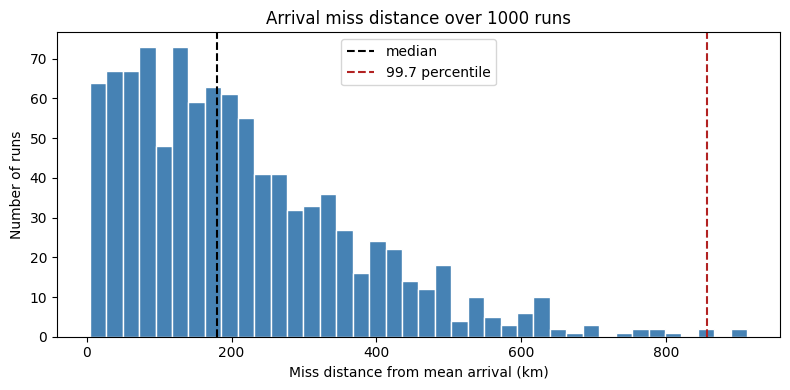

In [5]:
miss_km = np.linalg.norm(arrivals - arrivals.mean(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(miss_km, bins=40, color="steelblue", edgecolor="white")
ax.axvline(np.percentile(miss_km, 50), color="black", linestyle="--", label="median")
ax.axvline(
    np.percentile(miss_km, 99.7),
    color="firebrick",
    linestyle="--",
    label="99.7 percentile",
)
ax.set_xlabel("Miss distance from mean arrival (km)")
ax.set_ylabel("Number of runs")
ax.set_title(f"Arrival miss distance over {len(miss_km)} runs")
ax.legend()
fig.tight_layout()
plt.show()

## 3-sigma ellipse in the (X, Y) plane

Project the 3-D arrival cloud onto the (X, Y) plane and overlay the 3-sigma ellipse derived from the empirical 2x2 covariance. The ellipse semi-axes are 3-sigma_max and 3-sigma_min, where (sigma_max, sigma_min) are the square roots of the covariance matrix's eigenvalues; the rotation angle is the orientation of the major eigenvector.

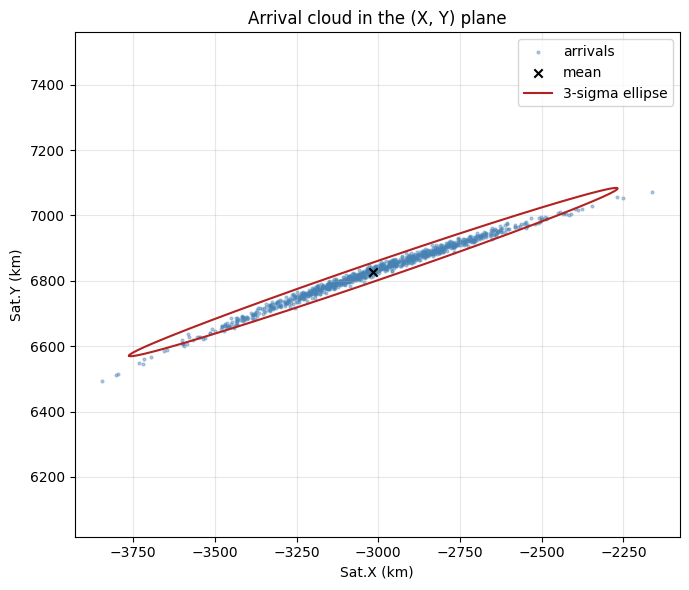

In [6]:
xy = arrivals[:, :2]
xy_mean = xy.mean(axis=0)
cov = np.cov(xy, rowvar=False)

eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
sigma_major, sigma_minor = np.sqrt(eigvals)
theta = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])

phi = np.linspace(0.0, 2 * np.pi, 200)
ellipse_local = 3.0 * np.array([sigma_major * np.cos(phi), sigma_minor * np.sin(phi)])
rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
ellipse = rot @ ellipse_local + xy_mean[:, None]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(xy[:, 0], xy[:, 1], s=4, alpha=0.4, color="steelblue", label="arrivals")
ax.scatter([xy_mean[0]], [xy_mean[1]], color="black", marker="x", label="mean")
ax.plot(ellipse[0], ellipse[1], color="firebrick", lw=1.5, label="3-sigma ellipse")
ax.set_xlabel("Sat.X (km)")
ax.set_ylabel("Sat.Y (km)")
ax.set_title("Arrival cloud in the (X, Y) plane")
ax.legend(loc="upper right")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Determinism contract

[`monte_carlo()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.monte_carlo) is deterministic in `(mission, n, perturb, seed)`. Two calls at the same seed produce bit-equal draws at every `run_id`; switching to a different seed produces a different draw set.

[`expand_monte_carlo_to_run_specs()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.expand_monte_carlo_to_run_specs) exposes the per-run `RunSpec.overrides` dict the workers would receive — useful for inspecting a draw set without paying the cost of running it. Two calls at the same `(perturb, n, seed)` build identical specs.

In [7]:
specs_a = expand_monte_carlo_to_run_specs(
    perturb, n=N, seed=SEED, script_path=script_path, output_dir=Path(".")
)
specs_b = expand_monte_carlo_to_run_specs(
    perturb, n=N, seed=SEED, script_path=script_path, output_dir=Path(".")
)
specs_c = expand_monte_carlo_to_run_specs(
    perturb, n=N, seed=SEED + 1, script_path=script_path, output_dir=Path(".")
)

same_seed_identical = all(
    a.overrides == b.overrides for a, b in zip(specs_a, specs_b, strict=False)
)
different_seed_changes = any(
    a.overrides != c.overrides for a, c in zip(specs_a, specs_c, strict=False)
)

print(f"Same seed reproduces every per-run override:    {same_seed_identical}")
print(f"Different seed yields a different draw set:     {different_seed_changes}")
print()
print("First three runs at SEED:")
for spec in specs_a[:3]:
    pretty = {k: round(v, 6) for k, v in spec.overrides.items()}
    print(f"  run_id={spec.run_id}: {pretty}")

Same seed reproduces every per-run override:    True
Different seed yields a different draw set:     True

First three runs at SEED:
  run_id=0: {'CoastTime.Value': 615.622936, 'Inj.Element1': 1.00177, 'Inj.Element2': 0.002277, 'Inj.Element3': -0.002967}
  run_id=1: {'CoastTime.Value': 625.65666, 'Inj.Element1': 1.002615, 'Inj.Element2': 0.001518, 'Inj.Element3': 0.00302}
  run_id=2: {'CoastTime.Value': 622.309289, 'Inj.Element1': 0.999758, 'Inj.Element2': -0.002852, 'Inj.Element3': -0.007749}


## Where to next

- **Variance reduction at small `n`.** [Notebook 05](https://astro-tools.github.io/gmat-sweep/examples/05_latin_hypercube/) compares plain Monte Carlo against Latin hypercube sampling at the same `perturb` and the same `n=64`, showing the stratification visually in a pair plot of the unit-cube samples.
- **Manifest-driven replay.** Pass `out=Path("./mc-run")` to anchor the per-run Parquet files and the `manifest.jsonl` under an explicit directory; [`Manifest.load`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.Manifest.load) reads the per-run overrides back without re-running.
- **Resume after a failure.** [Notebook 03](https://astro-tools.github.io/gmat-sweep/examples/03_killed_sweep_recovery/) walks through a kill mid-sweep followed by a programmatic [`Sweep.from_manifest(...).resume()`](https://astro-tools.github.io/gmat-sweep/resume/) that re-runs only the missing cells.
- **Distribution shapes outside the three shorthands.** [Parameter spec → Stochastic specs](https://astro-tools.github.io/gmat-sweep/parameter-spec/#stochastic-specs) documents the pre-frozen [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html) pass-through for triangular, beta, truncated normal, and so on.